In [401]:
import json
import base64
import qrcode
import requests
import datetime
import uuid
import matplotlib.pyplot as plt
from IPython import display
from pymongo import MongoClient
from typing import Optional, List
from didcomm.common.types import DID, VerificationMethodType, VerificationMaterial, VerificationMaterialFormat
from didcomm.did_doc.did_doc import DIDDoc, VerificationMethod, DIDCommService
from didcomm.did_doc.did_resolver import DIDResolver
from didcomm.message import Message, FromPrior
from didcomm.secrets.secrets_resolver_demo import SecretsResolverDemo
from didcomm.unpack import unpack, UnpackResult
from didcomm.common.resolvers import ResolversConfig
from didcomm.pack_encrypted import pack_encrypted, PackEncryptedConfig, PackEncryptedResult
from peerdid.core.did_doc_types import DIDCommServicePeerDID
from didcomm.secrets.secrets_util import generate_x25519_keys_as_jwk_dict, generate_ed25519_keys_as_jwk_dict, jwk_to_secret
from peerdid import peer_did
from peerdid.did_doc import DIDDocPeerDID
from peerdid.types import VerificationMaterialAuthentication, VerificationMethodTypeAuthentication, VerificationMaterialAgreement, VerificationMethodTypeAgreement, VerificationMaterialFormatPeerDID

In [402]:
secrets_resolver = SecretsResolverDemo()

In [403]:
class DIDResolverPeerDID(DIDResolver):
    def __init__(self, peer_did_resolver_profile=PeerDIDResolverProfile.DEFAULT):
        self.peer_did_resolver_profile = peer_did_resolver_profile

    async def resolve(self, did: DID) -> DIDDoc:
        """Resolves a PeerDID into a DIDDoc with formatted services and key IDs."""
        # Use your custom logic to resolve the DID
        did_doc_json = self._resolve_did_custom(did)  # Custom method to resolve DID
        print("did_doc_json:", did_doc_json)
        did_doc = DIDDocPeerDID.from_json(did_doc_json)

        # Normalize services for compatibility
        services = self.normalize_services(did_doc.service) if did_doc.service else []

        # Convert key IDs to sequential format if ROOTS_ID profile is enabled
        verification_methods = self.format_key_ids(did, did_doc.authentication + did_doc.key_agreement)

        return DIDDoc(
            id=did_doc.did,
            key_agreement=[
                vm.id for vm in verification_methods if vm.id in [m.id for m in did_doc.key_agreement]
            ],
            authentication=[
                vm.id for vm in verification_methods if vm.id in [m.id for m in did_doc.authentication]
            ],
            verification_method=[
                VerificationMethod(
                    id=m.id,
                    type=VerificationMethodType.JSON_WEB_KEY_2020,
                    controller=m.controller,
                    verification_material=VerificationMaterial(
                        format=VerificationMaterialFormat.JWK,
                        value=json.dumps(m.ver_material.value)
                    )
                )
                for m in did_doc.authentication + did_doc.key_agreement
            ],
            service=[
                {
                    "id": s.id,
                    "type": "DIDCommMessaging",
                    "serviceEndpoint": {
                        "uri": s.service_endpoint["uri"]
                        if isinstance(s.service_endpoint, dict) else s.service_endpoint,  # Ensure it's a string
                        "routingKeys": s.routing_keys if isinstance(s.routing_keys, list) else [],
                        "accept": s.accept if isinstance(s.accept, list) else ["didcomm/v2"]  # Ensure default accept type
                    }
                }
                for s in did_doc.service if isinstance(s, DIDCommServicePeerDID)
            ] if did_doc.service else []
        )

    def _resolve_did_custom(self, did: DID) -> dict:
        """
        Custom method to resolve a Peer DID into a DID document (DIDDoc).
        This implementation parses the Peer DID and constructs a DID document.
        """
        # Extract the method-specific identifier from the DID
        if not did.startswith("did:peer:"):
            raise ValueError(f"Invalid Peer DID: {did}")

        # Split the DID into its components
        _, method, method_specific_id = did.split(":")

        # Determine the Peer DID algorithm (numalgo)
        if method_specific_id.startswith("0"):
            # numalgo 0: Inception key only
            return self._resolve_numalgo_0(did, method_specific_id)
        elif method_specific_id.startswith("1"):
            # numalgo 1: Genesis version
            return self._resolve_numalgo_1(did, method_specific_id)
        elif method_specific_id.startswith("2"):
            # numalgo 2: Multiple keys and service
            return self._resolve_numalgo_2(did, method_specific_id)
        else:
            raise ValueError(f"Unsupported Peer DID algorithm: {method_specific_id}")

    def _resolve_numalgo_0(self, did: str, method_specific_id: str) -> dict:
        """
        Resolves a Peer DID using numalgo 0 (inception key only).
        """
        # Extract the public key from the method-specific identifier
        public_key_base58 = method_specific_id[1:]  # Remove the algorithm prefix

        # Construct the DID document
        return {
            "id": did,
            "authentication": [
                {
                    "id": f"{did}#key-1",
                    "type": "Ed25519VerificationKey2020",
                    "controller": did,
                    "publicKeyBase58": public_key_base58
                }
            ],
            "key_agreement": [],
            "service": []
        }

    def _resolve_numalgo_1(self, did: str, method_specific_id: str) -> dict:
        """
        Resolves a Peer DID using numalgo 1 (genesis version).
        """
        # Extract the public key and service information from the method-specific identifier
        # This is a placeholder implementation. Replace with actual logic.
        public_key_base58 = method_specific_id[1:]  # Remove the algorithm prefix

        # Construct the DID document
        return {
            "id": did,
            "authentication": [
                {
                    "id": f"{did}#key-1",
                    "type": "Ed25519VerificationKey2020",
                    "controller": did,
                    "publicKeyBase58": public_key_base58
                }
            ],
            "key_agreement": [],
            "service": []
        }

    def _resolve_numalgo_2(self, did: str, method_specific_id: str) -> dict:
        """
        Resolves a Peer DID using numalgo 2 (multiple keys and service).
        """
        # Extract the public keys and service information from the method-specific identifier
        # This is a placeholder implementation. Replace with actual logic.
        public_key_base58 = method_specific_id[1:]  # Remove the algorithm prefix

        # Construct the DID document
        return {
            "id": did,
            "authentication": [
                {
                    "id": f"{did}#key-1",
                    "type": "Ed25519VerificationKey2020",
                    "controller": did,
                    "publicKeyBase58": public_key_base58
                }
            ],
            "key_agreement": [
                {
                    "id": f"{did}#key-2",
                    "type": "X25519KeyAgreementKey2020",
                    "controller": did,
                    "publicKeyBase58": "xyz456"  # Replace with actual key material
                }
            ],
            "service": [
                {
                    "id": f"{did}#didcomm",
                    "type": "DIDCommMessaging",
                    "serviceEndpoint": {
                        "uri": "http://localhost:8080",
                        "routingKeys": [],
                        "accept": ["didcomm/v2"]
                    }
                }
            ]
        }

    def normalize_services(self, services) -> List[dict]:
        """Ensures service endpoints are properly structured."""
        normalized_services = []
        for service in services:
            if isinstance(service, DIDCommServicePeerDID):
                # Ensure the service ID is set to "#didcomm"
                service_id = "#didcomm"

                # Ensure serviceEndpoint is a dict with 'uri'
                service_endpoint = (
                    {"uri": service.service_endpoint}
                    if isinstance(service.service_endpoint, str)
                    else service.service_endpoint
                )

                # Normalize routing keys (ensure it's a list)
                routing_keys = service.routing_keys if isinstance(service.routing_keys, list) else []

                # Ensure the 'accept' attribute is correctly set
                accept = service.accept if hasattr(service, "accept") else ["didcomm/v2"]

                # Normalize the service structure
                normalized_services.append({
                    "id": service_id,
                    "serviceEndpoint": {
                        "uri": service_endpoint["uri"],  # Extract the URI
                        "routingKeys": routing_keys,
                        "accept": accept
                    },
                    "type": "DIDCommMessaging"
                })

        return normalized_services

    def format_key_ids(self, did: str, methods: List[VerificationMethod]) -> List[VerificationMethod]:
        """Formats key IDs based on the selected profile."""
        if self.peer_did_resolver_profile == PeerDIDResolverProfile.ROOTS_ID:
            new_methods = []

            # Assign sequential key IDs (key-1, key-2, ...)
            for index, method in enumerate(methods, start=1):
                new_id = f"{did}#key-{index}"  # Sequential key ID format
                method.id = new_id
                new_methods.append(method)

            return new_methods

        return methods

In [404]:
async def create_peer_did(
    auth_keys_count: int = 1,
    agreement_keys_count: int = 1,
    service_endpoint: Optional[str] = None,
    service_routing_keys: Optional[List[str]] = None
) -> str:
    # 1. Generate keys in JWK format
    agreem_keys = [generate_x25519_keys_as_jwk_dict() for _ in range(agreement_keys_count)]
    auth_keys = [generate_ed25519_keys_as_jwk_dict() for _ in range(auth_keys_count)]

    # 2. Prepare the keys for peer DID lib
    agreem_keys_peer_did = [
        VerificationMaterialAgreement(
            type=VerificationMethodTypeAgreement.JSON_WEB_KEY_2020,
            format=VerificationMaterialFormatPeerDID.JWK,
            value=k[1],
        )
        for k in agreem_keys
    ]
    auth_keys_peer_did = [
        VerificationMaterialAuthentication(
            type=VerificationMethodTypeAuthentication.JSON_WEB_KEY_2020,
            format=VerificationMaterialFormatPeerDID.JWK,
            value=k[1],
        )
        for k in auth_keys
    ]

    # 3. Generate service
    service = None
    if service_endpoint:
        service_data = {
            "id": "#didcomm",
            "type": "DIDCommMessaging",
            "serviceEndpoint": {
                "uri": service_endpoint,
                "routingKeys": service_routing_keys if service_routing_keys else [],
                "accept": ["didcomm/v2"]
            },
        }
        service = json.dumps(service_data)

    # 4. Call peer DID lib
    if len(auth_keys_peer_did) == 1 and not agreem_keys_peer_did and not service:
        did = peer_did.create_peer_did_numalgo_0(auth_keys_peer_did[0])
    else:
        did = peer_did.create_peer_did_numalgo_2(
            encryption_keys=agreem_keys_peer_did,
            signing_keys=auth_keys_peer_did,
            service=service,
        )

    # 5. Resolve the DID using your custom resolver
    did_doc = resolve_did_custom(did)
    print(did_doc)

    # 6. Extract the key IDs from the resolved DID document
    auth_kids = [vm.id for vm in did_doc.verification_method 
                if vm.id in did_doc.authentication]
    agreement_kids = [vm.id for vm in did_doc.verification_method 
                    if vm.id in did_doc.key_agreement]
    print("auth_kids:", auth_kids)
    print("agreement_kids:", agreement_kids)

    # 7. Store the private keys with appropriate IDs
    for idx, auth_key in enumerate(auth_keys):
        if idx < len(auth_kids):
            private_key = auth_key[0]
            private_key["kid"] = auth_kids[idx]
            await secrets_resolver.add_key(jwk_to_secret(private_key))
            print("private auth key:", private_key)

    for idx, agreem_key in enumerate(agreem_keys):
        if idx < len(agreement_kids):
            private_key = agreem_key[0]
            private_key["kid"] = agreement_kids[idx]
            await secrets_resolver.add_key(jwk_to_secret(private_key))
            print("private key-agreement key:", private_key)

    return did

### Alice get OOB from Mediator

In [405]:
#oob_url = requests.get("http://127.0.0.1:8000/oob_url").text
oob_url = requests.get("http://localhost:8080/oob_url").text

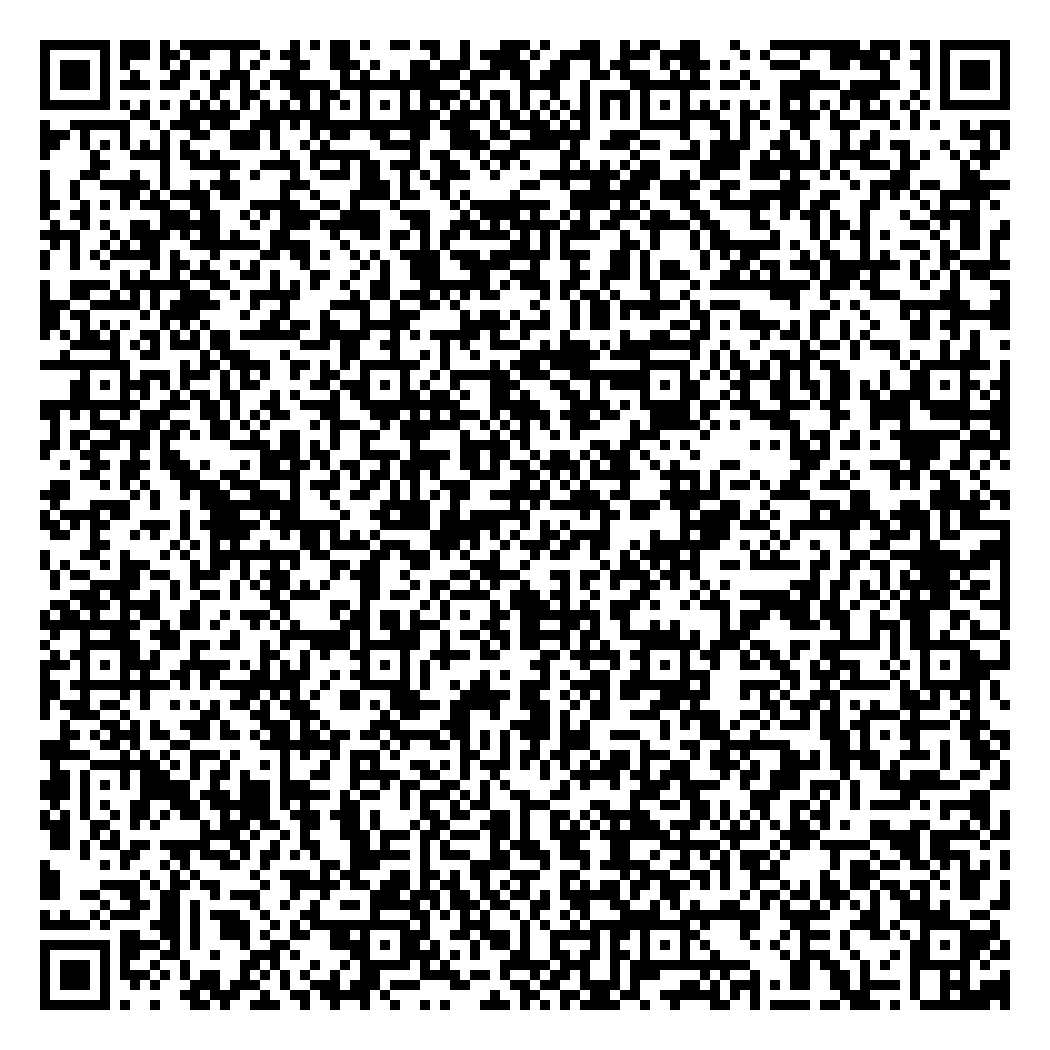

In [406]:
im = qrcode.make(oob_url)
im.save('qr.png')
display.Image('qr.png',width=500,height=500)

In [407]:
received_msg_encoded = oob_url.split("=")[1]
received_msg_decoded = json.loads(str(base64.urlsafe_b64decode(received_msg_encoded + "=="), "utf-8"))

alice_did_for_mediator = await create_peer_did(1, 1, "http://localhost:8080")


print("Alice's DID:", alice_did_for_mediator)


NameError: name 'resolve_did_custom' is not defined

### Alice request mediate

In [351]:
alice_mediate_grant = Message(
    custom_headers = {"return_route": "all"},
    id = str(uuid.uuid4()),
    type = "https://didcomm.org/coordinate-mediation/2.0/mediate-request",
    body = {}
)

In [352]:
alice_mediate_grant_packed = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID(peer_did_resolver_profile=PeerDIDResolverProfile.ROOTS_ID)
    ),
    message = alice_mediate_grant,
    frm = alice_did_for_mediator,
    to = received_msg_decoded["from"],
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
print(alice_mediate_grant_packed)

AttributeError: 'DIDResolverPeerDID' object has no attribute '_resolve_did_custom'

### Sending to Mediator

In [65]:
mediator_did_doc = json.loads(peer_did.resolve_peer_did(received_msg_decoded["from"]))
mediator_endpoint = mediator_did_doc["service"][0]["serviceEndpoint"]["uri"]
print(mediator_endpoint)

http://localhost:8080


In [66]:
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp = requests.post(mediator_endpoint, headers=headers, json = json.loads(alice_mediate_grant_packed.packed_msg))


In [67]:
print(resp.json())

{'error': 'Could not unpack message'}


### Get mediator grant response

In [81]:
mediator_unpack_msg = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp.json()
)
print(mediator_unpack_msg.message.type)
print("Routing Key: " + mediator_unpack_msg.message.body["routing_did"])
print("Mediator new DID: " + mediator_unpack_msg.message.from_prior.sub)
# mediator rotated did
mediator_routing_key = mediator_unpack_msg.message.body["routing_did"]
mediator_did = mediator_unpack_msg.message.from_prior.sub

https://didcomm.org/coordinate-mediation/2.0/mediate-grant
Routing Key: did:peer:2.Ez6LSipE2TzyugN58SBHf6MRBwFdmhADjR9KJQ7NVUtmmnwbr.Vz6MkguBECtSnXWS87jfCEhJ7RywfrFjoh9nuaxjWSMfaYzv5.SeyJpZCI6Im5ldy1pZCIsInQiOiJkbSIsInMiOiJodHRwczovL21lZGlhdG9yLnJvb3RzaWQuY2xvdWQiLCJhIjpbImRpZGNvbW0vdjIiXX0
Mediator new DID: did:peer:2.Ez6LSkYKoVSkXg6sDSXrNWwU1BZVr7fUmW3acFfKU2bg7YGoJ.Vz6MkeVjARsxKbJJd64fqvTnwbF8EED5X4AYgYXeXPanv2jLL.SeyJpZCI6Im5ldy1pZCIsInQiOiJkbSIsInMiOiJodHRwczovL21lZGlhdG9yLnJvb3RzaWQuY2xvdWQiLCJhIjpbImRpZGNvbW0vdjIiXX0


### Keylist update

Alice create a new DID to share with  other peers using mediator routing keys 

In [82]:
#alice_did_new = await create_peer_did(1, 1, service_endpoint=mediator_endpoint, service_routing_keys=[mediator_routing_key])
alice_did_for_bob = await create_peer_did(1, 1, service_endpoint=[{"uri": mediator_routing_key}])

print("Alice's DID for Bob:", alice_did_for_bob)

Generated Service Data: {
    "id": "#didcomm",
    "type": "DIDCommMessaging",
    "serviceEndpoint": {
        "uri": [
            {
                "uri": "did:peer:2.Ez6LSipE2TzyugN58SBHf6MRBwFdmhADjR9KJQ7NVUtmmnwbr.Vz6MkguBECtSnXWS87jfCEhJ7RywfrFjoh9nuaxjWSMfaYzv5.SeyJpZCI6Im5ldy1pZCIsInQiOiJkbSIsInMiOiJodHRwczovL21lZGlhdG9yLnJvb3RzaWQuY2xvdWQiLCJhIjpbImRpZGNvbW0vdjIiXX0"
            }
        ],
        "routingKeys": [],
        "accept": [
            "didcomm/v2"
        ]
    }
}
Alice's DID for Bob: did:peer:2.Ez6LScpV2KgEUnp5Vucfpg1XT2S43ydBKUdL5jRWDLDH1cKDp.Vz6MkqF91KCTWqcP9fgJWzcuxy3TgpuE6uAxp849qKAkFSTf2.SeyJpZCI6IiNkaWRjb21tIiwidCI6ImRtIiwicyI6eyJ1cmkiOlt7InVyaSI6ImRpZDpwZWVyOjIuRXo2TFNpcEUyVHp5dWdONThTQkhmNk1SQndGZG1oQURqUjlLSlE3TlZVdG1tbndici5WejZNa2d1QkVDdFNuWFdTODdqZkNFaEo3Unl3ZnJGam9oOW51YXhqV1NNZmFZenY1LlNleUpwWkNJNkltNWxkeTFwWkNJc0luUWlPaUprYlNJc0luTWlPaUpvZEhSd2N6b3ZMMjFsWkdsaGRHOXlMbkp2YjNSemFXUXVZMnh2ZFdRaUxDSmhJanBiSW1ScFpHTnZiVzB2ZGpJaVhYMCJ9XSwiciI6W10sImE

Alice create and send the keylist update message

In [83]:
alice_keylist_update = Message(
    id = "unique-id-293e9a922efff",
    type = "https://didcomm.org/coordinate-mediation/2.0/keylist-update",
    body = {
        "updates":[
        {
            "recipient_did": alice_did_for_bob,
            "action": "add"
        }
    ]
    }
)

In [84]:
alice_keylist_update_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_keylist_update,
    frm = alice_did_for_mediator,
    to = mediator_did,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)

In [85]:
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp = requests.post(mediator_endpoint, headers=headers, data = alice_keylist_update_packed_msg.packed_msg)

In [86]:
mediator_unpack_msg2 = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp.json()
)
print(mediator_unpack_msg2.message.type)
print(mediator_unpack_msg2.message.body)


https://didcomm.org/coordinate-mediation/2.0/keylist-update-response
{'updated': [{'recipient_did': 'did:peer:2.Ez6LScpV2KgEUnp5Vucfpg1XT2S43ydBKUdL5jRWDLDH1cKDp.Vz6MkqF91KCTWqcP9fgJWzcuxy3TgpuE6uAxp849qKAkFSTf2.SeyJpZCI6IiNkaWRjb21tIiwidCI6ImRtIiwicyI6eyJ1cmkiOlt7InVyaSI6ImRpZDpwZWVyOjIuRXo2TFNpcEUyVHp5dWdONThTQkhmNk1SQndGZG1oQURqUjlLSlE3TlZVdG1tbndici5WejZNa2d1QkVDdFNuWFdTODdqZkNFaEo3Unl3ZnJGam9oOW51YXhqV1NNZmFZenY1LlNleUpwWkNJNkltNWxkeTFwWkNJc0luUWlPaUprYlNJc0luTWlPaUpvZEhSd2N6b3ZMMjFsWkdsaGRHOXlMbkp2YjNSemFXUXVZMnh2ZFdRaUxDSmhJanBiSW1ScFpHTnZiVzB2ZGpJaVhYMCJ9XSwiciI6W10sImEiOlsiZGlkY29tbS92MiJdfX0', 'action': 'add', 'result': 'success'}]}


### Alice can now send her DID to Bob. Copy Alice's DID into Bob's notebook, and follows Bob's notebook

In [87]:
print(alice_did_for_bob)

did:peer:2.Ez6LScpV2KgEUnp5Vucfpg1XT2S43ydBKUdL5jRWDLDH1cKDp.Vz6MkqF91KCTWqcP9fgJWzcuxy3TgpuE6uAxp849qKAkFSTf2.SeyJpZCI6IiNkaWRjb21tIiwidCI6ImRtIiwicyI6eyJ1cmkiOlt7InVyaSI6ImRpZDpwZWVyOjIuRXo2TFNpcEUyVHp5dWdONThTQkhmNk1SQndGZG1oQURqUjlLSlE3TlZVdG1tbndici5WejZNa2d1QkVDdFNuWFdTODdqZkNFaEo3Unl3ZnJGam9oOW51YXhqV1NNZmFZenY1LlNleUpwWkNJNkltNWxkeTFwWkNJc0luUWlPaUprYlNJc0luTWlPaUpvZEhSd2N6b3ZMMjFsWkdsaGRHOXlMbkp2YjNSemFXUXVZMnh2ZFdRaUxDSmhJanBiSW1ScFpHTnZiVzB2ZGpJaVhYMCJ9XSwiciI6W10sImEiOlsiZGlkY29tbS92MiJdfX0


### Alice check status of queued messages from the Mediator

In [ ]:
alice_status_check = Message(
    id = "unique-id-293e9a922efffxxx",
    type = "https://didcomm.org/messagepickup/3.0/status-request",
    body = {}
)

In [ ]:
alice_status_check_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_status_check,
    to = mediator_did,
    frm = alice_did_for_mediator,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp3 = requests.post(mediator_endpoint, headers=headers, data = alice_status_check_packed_msg.packed_msg)

In [ ]:
mediator_unpack_status = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp3.json()
)
print(mediator_unpack_status.message.type)
print("Messages in Mediator queue: " + str(mediator_unpack_status.message.body["message_count"]))

### If there are messages, Alice can pickup from the mediator (delivery request)

In [ ]:
alice_delivery_request = Message(
    id = "unique-id-293e9a922efffxxxff",
    type = "https://didcomm.org/messagepickup/3.0/delivery-request",
    body = {"limit": 1}
)

In [ ]:
alice_delivery_request_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_delivery_request,
    to = mediator_did,
    frm = alice_did_for_mediator,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp4 = requests.post(mediator_endpoint, headers=headers, data = alice_delivery_request_packed_msg.packed_msg)

In [ ]:
mediator_delivery = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp4.json()
)
print(mediator_delivery.message.type)
print(mediator_delivery.message.body)

In [ ]:
bob_packed_msg = mediator_delivery.message.attachments[0].data.json
msg_id = mediator_delivery.message.attachments[0].id

In [ ]:
print(bob_packed_msg)

In [ ]:
bob_msg = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= bob_packed_msg
)

In [ ]:
print("Message ID:", msg_id)
print(bob_msg.message.body["content"])

### Alice acknowledge so the mediator can delete the message

In [ ]:
alice_ack = Message(
    id = "unique-id-293e9a922efffxxxffsss",
    type = "https://didcomm.org/messagepickup/3.0/messages-received",
    body = {"message_id_list": [msg_id]}
)

In [ ]:
alice_ack_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_ack,
    to = mediator_did,
    frm = alice_did_for_mediator,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp5 = requests.post(mediator_endpoint, headers=headers, data = alice_ack_packed_msg.packed_msg)

In [ ]:
mediator_ack_status = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp5.json()
)
print(mediator_ack_status.message.type)
print(mediator_ack_status.message.body)